# Лабораторная работа №6
## Анализ и прогнозирование временного ряда.

### Выполнил студент группы РТ5-61Б Иванов А.А.

**Цель лабораторной работы**: изучение основных методов анализа и прогнозирование временных рядов.


Dataset: https://www.kaggle.com/datasets/shenba/time-series-datasets?select=daily-minimum-temperatures-in-me.csv

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

from gplearn.genetic import SymbolicRegressor

from prophet import Prophet

from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

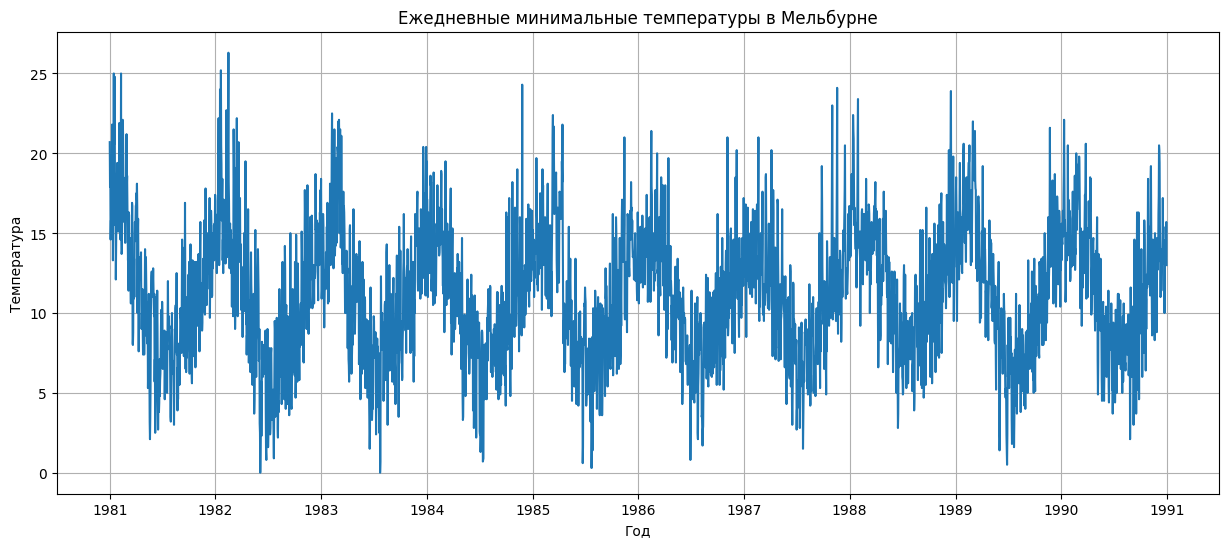

In [34]:
url = "daily-minimum-temperatures-in-me.csv" 
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

df.columns = ['Temp']

df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')
df = df.dropna()

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Temp'])
plt.title('Ежедневные минимальные температуры в Мельбурне')
plt.xlabel('Год')
plt.ylabel('Температура')
plt.grid(True)
plt.show()

Размер обучающей выборки: 2917
Размер тестовой выборки: 730


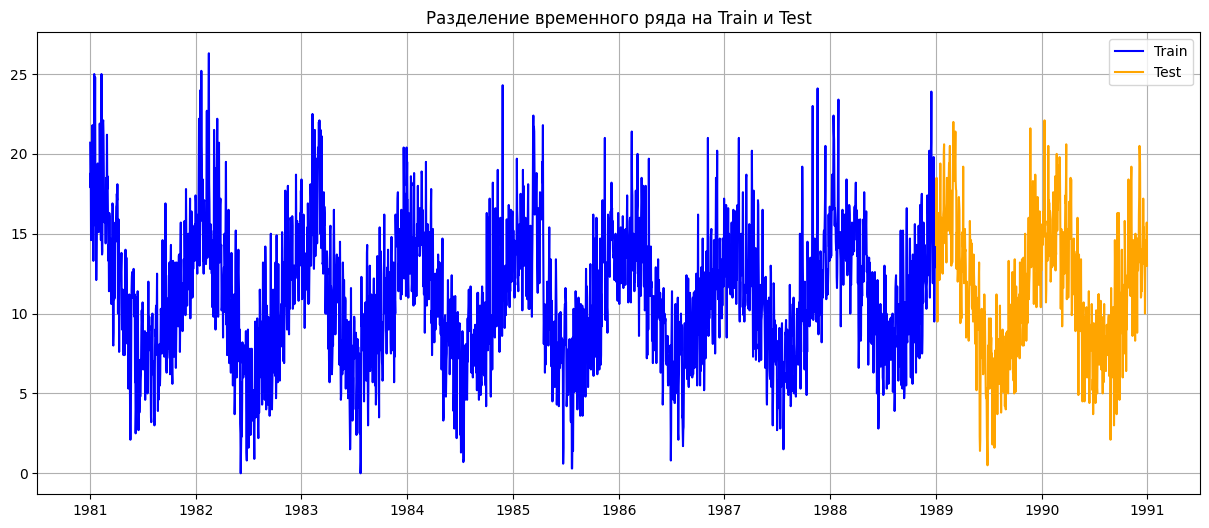

In [35]:
train_size = len(df) - 730
train, test = train_test_split(df, train_size=train_size, shuffle=False)

print(f"Размер обучающей выборки: {len(train)}")
print(f"Размер тестовой выборки: {len(test)}")

plt.figure(figsize=(15, 6))
plt.plot(train.index, train['Temp'], label='Train', color='blue')
plt.plot(test.index, test['Temp'], label='Test', color='orange')
plt.title('Разделение временного ряда на Train и Test')
plt.legend()
plt.grid(True)
plt.show()

/home/alexandr/projects/TML/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/alexandr/projects/TML/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/alexandr/projects/TML/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/alexandr/projects/TML/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given wit

ARIMA MAE: 3.76 °C


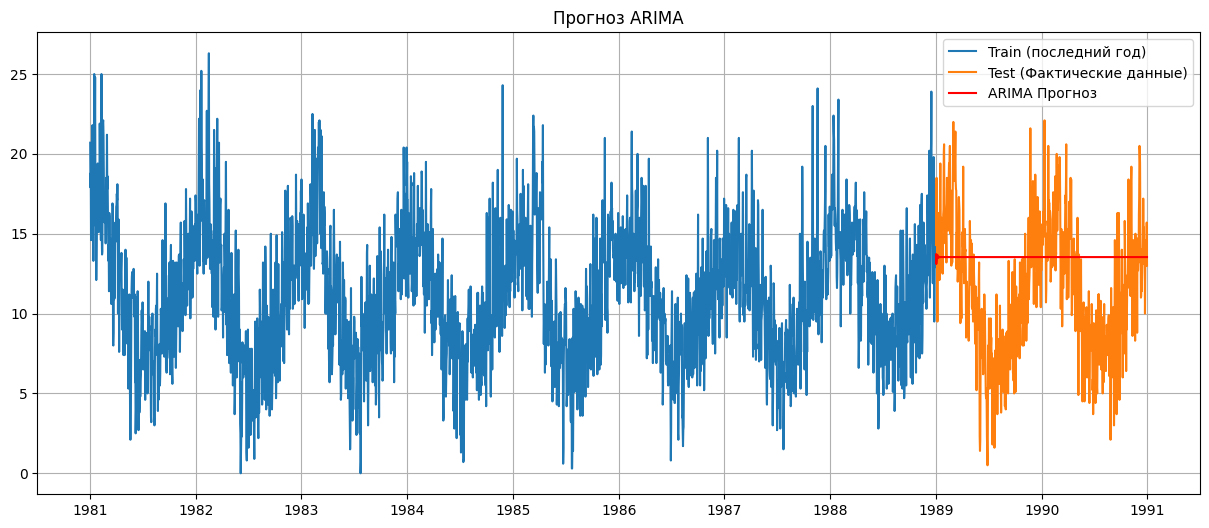

In [36]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

# модель ARIMA
model_arima = ARIMA(train['Temp'], order=(5, 1, 0))
model_arima_fit = model_arima.fit()

forecast_arima = model_arima_fit.forecast(steps=len(test))

mae_arima = mean_absolute_error(test['Temp'], forecast_arima)
print(f"ARIMA MAE: {mae_arima:.2f} °C")

plt.figure(figsize=(15, 6))
plt.plot(train.index[-train_size:], train['Temp'].tail(train_size), label='Train (последний год)')
plt.plot(test.index, test['Temp'], label='Test (Фактические данные)')
plt.plot(test.index, forecast_arima, label='ARIMA Прогноз', color='red')
plt.title('Прогноз ARIMA')
plt.legend()
plt.grid(True)
plt.show()

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    48.87      6.48285e+30       15          4.92983          5.22993     13.40s
   1    34.87      9.45842e+07       31          3.45834          3.36943     10.25s
   2    54.48      3.41373e+09       31          3.23114          3.49531     10.97s
   3    29.39      6.17061e+07       39          3.22425           3.4131      8.60s
   4    36.44      2.61954e+06       39          3.21187          3.52444      8.73s
   5    35.68      1.54937e+06       25          3.21452            3.729      8.02s
   6    29.79           294932       13          3.18577          3.78698      7.05s
   7    25.25      4.25419e+06       33          3.19622          3.58775      6.08s
   8    18.99          52589.3       13          3.20077          3.65209  

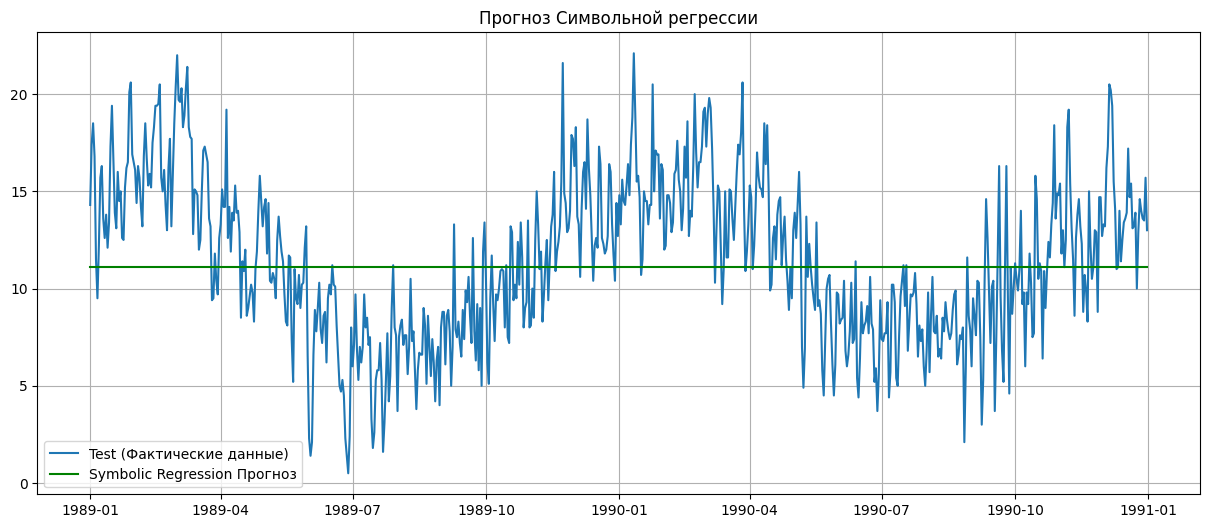

In [37]:
# создаем числовой индекс времени
X_train = np.arange(len(train)).reshape(-1, 1)
y_train = train['Temp'].values

# индексы для тестовой выборки будут продолжать индексы обучающей
X_test = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)
y_test = test['Temp'].values

est_gp = SymbolicRegressor(population_size=1000,
                           generations=20, 
                           stopping_criteria=0.01,
                           p_crossover=0.7, 
                           p_subtree_mutation=0.1,
                           p_hoist_mutation=0.05, 
                           p_point_mutation=0.1,
                           max_samples=0.9, 
                           verbose=1,
                           random_state=42)

est_gp.fit(X_train, y_train)

forecast_gp = est_gp.predict(X_test)

mae_gp = mean_absolute_error(y_test, forecast_gp)
print(f"Symbolic Regression MAE: {mae_gp:.2f}")

print("формула:", est_gp._program)

plt.figure(figsize=(15, 6))
plt.plot(test.index, y_test, label='Test (Фактические данные)')
plt.plot(test.index, forecast_gp, label='Symbolic Regression Прогноз', color='green')
plt.title('Прогноз Символьной регрессии')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
df_prophet = pd.DataFrame({
    'ds': df.index,
    'y': df['Temp'].values
})

train_prophet = df_prophet.iloc[:-train_size]
test_prophet = df_prophet.iloc[-train_size:]

model_prophet = Prophet(daily_seasonality=False)
model_prophet.fit(train_prophet)

future = model_prophet.make_future_dataframe(periods=train_size)

forecast_prophet_full = model_prophet.predict(future)

forecast_prophet = forecast_prophet_full['yhat'].iloc[-train_size:].values

mae_prophet = mean_absolute_error(test_prophet['y'], forecast_prophet)
print(f"Prophet MAE: {mae_prophet:.2f}")

16:27:15 - cmdstanpy - INFO - Chain [1] start processing
16:27:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 3.68


In [ ]:
model_sarima = SARIMAX(train['Temp'], 
                       order=(2, 1, 1), 
                       seasonal_order=(1, 0, 0, 365),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

model_sarima_fit = model_sarima.fit(disp=False)

forecast_sarima = model_sarima_fit.predict(start=len(train), end=len(train)+len(test)-1)

mae_sarima = mean_absolute_error(test['Temp'], forecast_sarima)
print(f"SARIMA MAE: {mae_sarima:.2f}")

/home/alexandr/projects/TML/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/alexandr/projects/TML/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
def create_lags(series, lags=30):
    X, y = [], []
    for i in range(len(series) - lags):
        X.append(series[i:(i + lags)])
        y.append(series[i + lags])
    return np.array(X), np.array(y)

temp_values = df['Temp'].values
X_rf, y_rf = create_lags(temp_values, lags=30)

test_length = len(test)

X_train_rf, X_test_rf = X_rf[:-test_length], X_rf[-test_length:]
y_train_rf, y_test_rf = y_rf[:-test_length], y_rf[-test_length:]

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_rf, y_train_rf)

forecast_rf = model_rf.predict(X_test_rf)
mae_rf = mean_absolute_error(y_test_rf, forecast_rf)

print(f"Random Forest MAE: {mae_rf:.2f}")

Random Forest (Ручные лаги) MAE: 1.73 °C


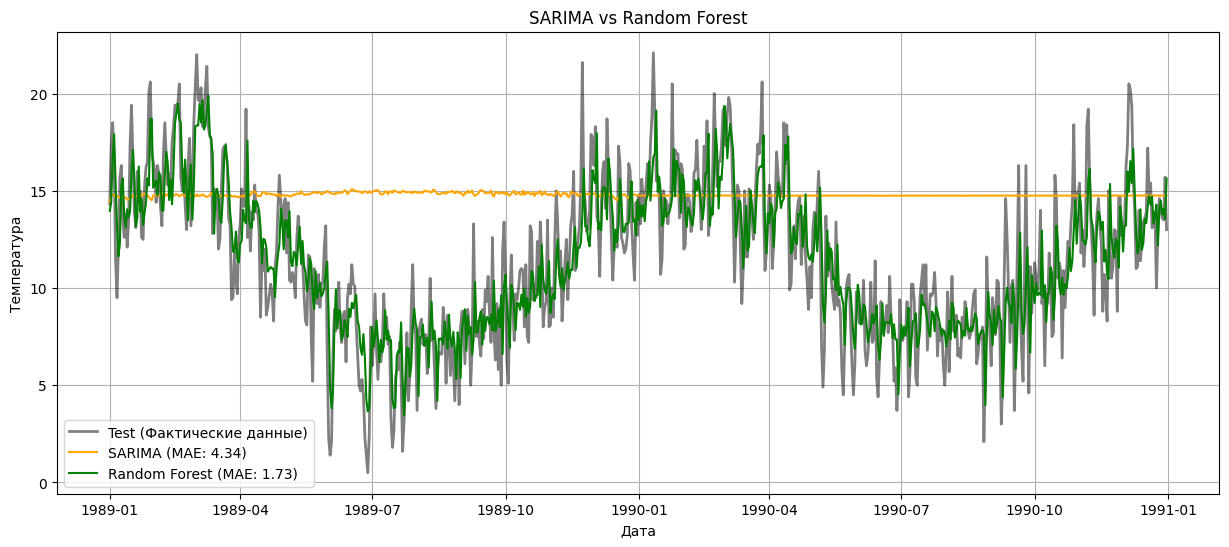

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(test.index, test['Temp'], label='Test (Фактические данные)', color='black', alpha=0.5, linewidth=2)

plt.plot(test.index, forecast_sarima, label=f'SARIMA (MAE: {mae_sarima:.2f})', color='orange')
plt.plot(test.index, forecast_rf, label=f'Random Forest (MAE: {mae_rf:.2f})', color='green')

plt.title('SARIMA vs Random Forest')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.legend()
plt.grid(True)
plt.show()

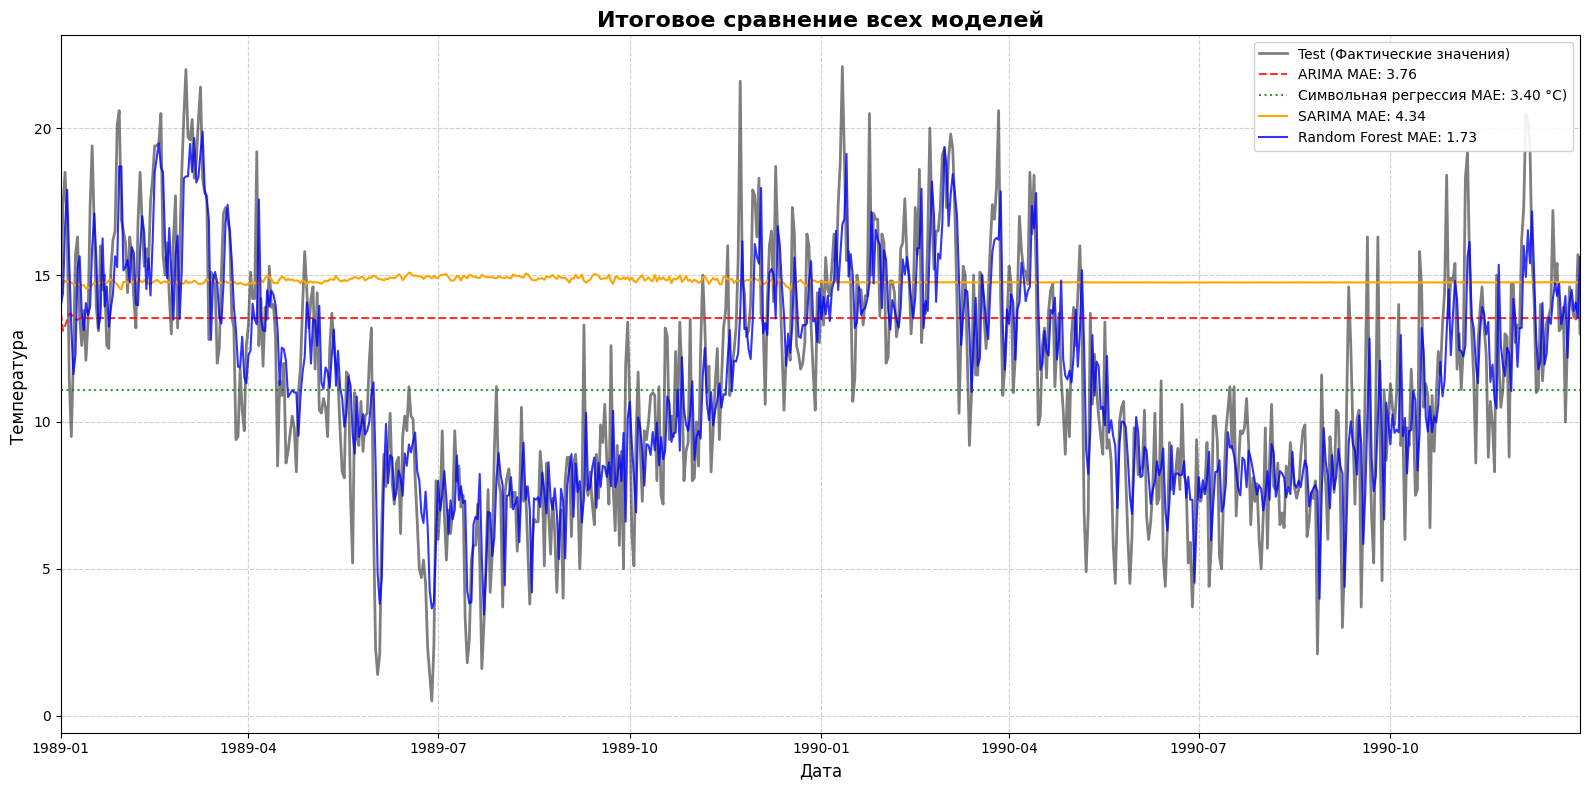

In [ ]:
plt.figure(figsize=(16, 8))

plt.plot(test.index, test['Temp'], 
         label='Test (Фактические значения)', 
         color='black', alpha=0.5, linewidth=2)

plt.plot(test.index, forecast_arima, 
         label=f'ARIMA MAE: {mae_arima:.2f}', 
         color='red', linestyle='--', alpha=0.8)

plt.plot(test.index, forecast_gp, 
         label=f'Символьная регрессия MAE: {mae_gp:.2f}', 
         color='green', linestyle=':', alpha=0.8)

plt.plot(test.index, forecast_sarima, 
         label=f'SARIMA MAE: {mae_sarima:.2f}', 
         color='orange', linewidth=1.5)

plt.plot(test.index, forecast_rf, 
         label=f'Random Forest MAE: {mae_rf:.2f}', 
         color='blue', linewidth=1.5, alpha=0.8)

plt.title('Итоговое сравнение всех моделей', 
          fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура ', fontsize=12)
plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(test.index[0], test.index[-1])

plt.tight_layout()
plt.show()